In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# Load gnomAD variants for OTOF
gnomad = pd.read_csv("../data/gnomad_otof_variants.csv")

# How many variants did we load?
print(f"Loaded {len(gnomad)} gnomAD variants for OTOF.")
print(f"Columns: {gnomad.shape[1]}")

Loaded 9601 gnomAD variants for OTOF.
Columns: 72


/var/folders/v2/52hczvlj4c9b366t1jxbm4sw0000gp/T/ipykernel_97995/2015216702.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  gnomad = pd.read_csv("../data/gnomad_otof_variants.csv")


In [3]:
gnomad.columns.tolist()

['gnomAD ID',
 'Chromosome',
 'Position',
 'rsIDs',
 'Reference',
 'Alternate',
 'Source',
 'Filters - exomes',
 'Filters - genomes',
 'Transcript',
 'HGVS Consequence',
 'Protein Consequence',
 'Transcript Consequence',
 'VEP Annotation',
 'ClinVar Germline Classification',
 'ClinVar Variation ID',
 'Flags',
 'Allele Count',
 'Allele Number',
 'Allele Frequency',
 'Homozygote Count',
 'Hemizygote Count',
 'Filters - joint',
 'GroupMax FAF group',
 'GroupMax FAF frequency',
 'cadd',
 'revel_max',
 'spliceai_ds_max',
 'pangolin_largest_ds',
 'phylop',
 'sift_max',
 'polyphen_max',
 'Allele Count African/African American',
 'Allele Number African/African American',
 'Homozygote Count African/African American',
 'Hemizygote Count African/African American',
 'Allele Count Admixed American',
 'Allele Number Admixed American',
 'Homozygote Count Admixed American',
 'Hemizygote Count Admixed American',
 'Allele Count Ashkenazi Jewish',
 'Allele Number Ashkenazi Jewish',
 'Homozygote Count Ash

In [4]:
gnomad.head()

,gnomAD ID,Chromosome,Position,rsIDs,Reference,Alternate,Source,Filters - exomes,Filters - genomes,Transcript,...,Homozygote Count Amish,Hemizygote Count Amish,Allele Count South Asian,Allele Number South Asian,Homozygote Count South Asian,Hemizygote Count South Asian,Allele Count Remaining,Allele Number Remaining,Homozygote Count Remaining,Hemizygote Count Remaining
0,2-26457969-T-C,2,26457969,rs955397236,T,C,gnomAD Exomes,PASS,NaN,ENST00000272371.7,...,0,0,0,80300,0,0,0,57156,0,0
1,2-26457972-G-C,2,26457972,rs1421241299,G,C,"gnomAD Exomes,gnomAD Genomes",PASS,PASS,ENST00000272371.7,...,0,0,0,81268,0,0,1,57938,0,0
2,2-26457972-GAA-G,2,26457972,NaN,GAA,G,gnomAD Exomes,PASS,NaN,ENST00000272371.7,...,0,0,0,81264,0,0,1,57960,0,0
3,2-26457973-A-G,2,26457973,NaN,A,G,gnomAD Exomes,PASS,NaN,ENST00000272371.7,...,0,0,0,81450,0,0,0,58062,0,0
4,2-26457976-G-A,2,26457976,NaN,G,A,gnomAD Exomes,PASS,NaN,ENST00000272371.7,...,0,0,6,82014,0,0,0,58360,0,0


In [5]:
# Distribution of allele frequencies
gnomad["Allele Frequency"].describe()

count    9.601000e+03
mean     5.961493e-04
std      1.509338e-02
min      6.194681e-07
25%      6.213666e-07
50%      1.239776e-06
75%      3.732021e-06
max      6.811997e-01
Name: Allele Frequency, dtype: float64

In [6]:
# How many gnomAD variants have a ClinVar classification?
has_clinvar = gnomad["ClinVar Germline Classification"].notna()
print(f"gnomAD variants with ClinVar annotation: {has_clinvar.sum()}")
print(f"gnomAD variants without ClinVar annotation: {(~has_clinvar).sum()}")
print(f"Total: {len(gnomad)}")

gnomAD variants with ClinVar annotation: 1682
gnomAD variants without ClinVar annotation: 7919
Total: 9601


In [7]:
# Distribution of ClinVar classifications among gnomAD variants
clinvar_classifications = gnomad.loc[has_clinvar, "ClinVar Germline Classification"].value_counts()
clinvar_classifications

ClinVar Germline Classification
Likely benign                                   789
Uncertain significance                          385
Conflicting classifications of pathogenicity    227
Pathogenic                                       97
Likely pathogenic                                58
Benign                                           56
Benign/Likely benign                             43
Pathogenic/Likely pathogenic                     21
not provided                                      6
Name: count, dtype: int64

In [8]:
# Working subset: gnomAD variants that are also in ClinVar
df_merged = gnomad[has_clinvar].copy()

print(f"Working dataset: {len(df_merged)} variants with both gnomAD and ClinVar data.")

Working dataset: 1682 variants with both gnomAD and ClinVar data.


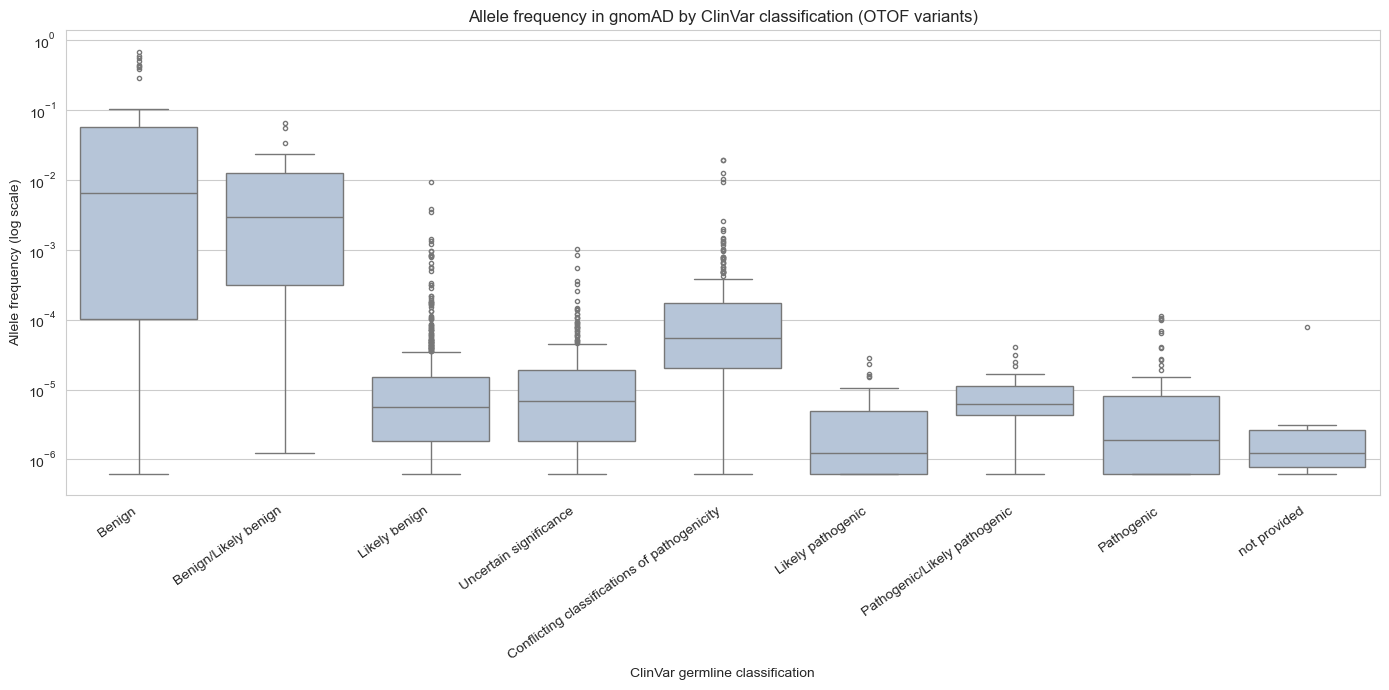

In [9]:
# Order categories meaningfully (from benign to pathogenic)
classification_order = [
    "Benign",
    "Benign/Likely benign",
    "Likely benign",
    "Uncertain significance",
    "Conflicting classifications of pathogenicity",
    "Likely pathogenic",
    "Pathogenic/Likely pathogenic",
    "Pathogenic",
    "not provided",
]

# Box plot of allele frequency by classification (log scale on Y axis)
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_merged,
    x="ClinVar Germline Classification",
    y="Allele Frequency",
    order=classification_order,
    color="lightsteelblue",
    fliersize=3,
)
plt.yscale("log")
plt.title("Allele frequency in gnomAD by ClinVar classification (OTOF variants)")
plt.xlabel("ClinVar germline classification")
plt.ylabel("Allele frequency (log scale)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

# Save figure
plt.savefig("../results/gnomad_frequency_by_classification.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# Identify suspicious P/LP variants with high allele frequency in gnomAD
# Threshold: 0.5% allele frequency (BS1 criterion in ACMG/AMP guidelines)
THRESHOLD = 0.005

pathogenic_classes = ["Pathogenic", "Likely pathogenic", "Pathogenic/Likely pathogenic"]

suspicious = df_merged[
    (df_merged["ClinVar Germline Classification"].isin(pathogenic_classes))
    & (df_merged["Allele Frequency"] > THRESHOLD)
]

print(f"Pathogenic variants with AF > {THRESHOLD}: {len(suspicious)}")
suspicious[["gnomAD ID", "HGVS Consequence", "Protein Consequence", 
            "ClinVar Germline Classification", "Allele Frequency"]]

Pathogenic variants with AF > 0.005: 0


,gnomAD ID,HGVS Consequence,Protein Consequence,ClinVar Germline Classification,Allele Frequency


In [11]:
# Look at the top 15 most frequent P/LP variants in gnomAD
pathogenic_classes = ["Pathogenic", "Likely pathogenic", "Pathogenic/Likely pathogenic"]

top_pathogenic = df_merged[
    df_merged["ClinVar Germline Classification"].isin(pathogenic_classes)
].sort_values("Allele Frequency", ascending=False).head(15)

top_pathogenic[["gnomAD ID", "HGVS Consequence", "Protein Consequence", 
                "VEP Annotation", "ClinVar Germline Classification", 
                "Allele Frequency", "Homozygote Count"]]

,gnomAD ID,HGVS Consequence,Protein Consequence,VEP Annotation,ClinVar Germline Classification,Allele Frequency,Homozygote Count
4809,2-26476018-G-A,p.Arg963Ter,p.Arg963Ter,stop_gained,Pathogenic,0.000111,1
5624,2-26477473-GC-G,p.Gly783AlafsTer17,p.Gly783AlafsTer17,frameshift_variant,Pathogenic,0.000106,0
1571,2-26463969-C-G,p.Glu1700Gln,p.Glu1700Gln,missense_variant,Pathogenic,0.000103,1
4088,2-26473999-G-A,p.Arg1134Ter,p.Arg1134Ter,stop_gained,Pathogenic,0.000099,0
164,2-26458218-C-T,p.Arg1172Gln,p.Arg1172Gln,missense_variant,Pathogenic,0.000068,1
5412,2-26477210-G-A,p.Gln829Ter,p.Gln829Ter,stop_gained,Pathogenic,0.000065,0
9188,2-26527910-C-T,p.Trp50Ter,p.Trp50Ter,stop_gained,Pathogenic/Likely pathogenic,0.000041,0
9506,2-26558540-G-T,p.Ser11Ter,p.Ser11Ter,stop_gained,Pathogenic,0.000040,0
6055,2-26479356-G-A,p.Arg708Ter,p.Arg708Ter,stop_gained,Pathogenic,0.000039,0
2050,2-26465753-A-G,p.Ile1573Thr,p.Ile1573Thr,missense_variant,Pathogenic/Likely pathogenic,0.000031,0


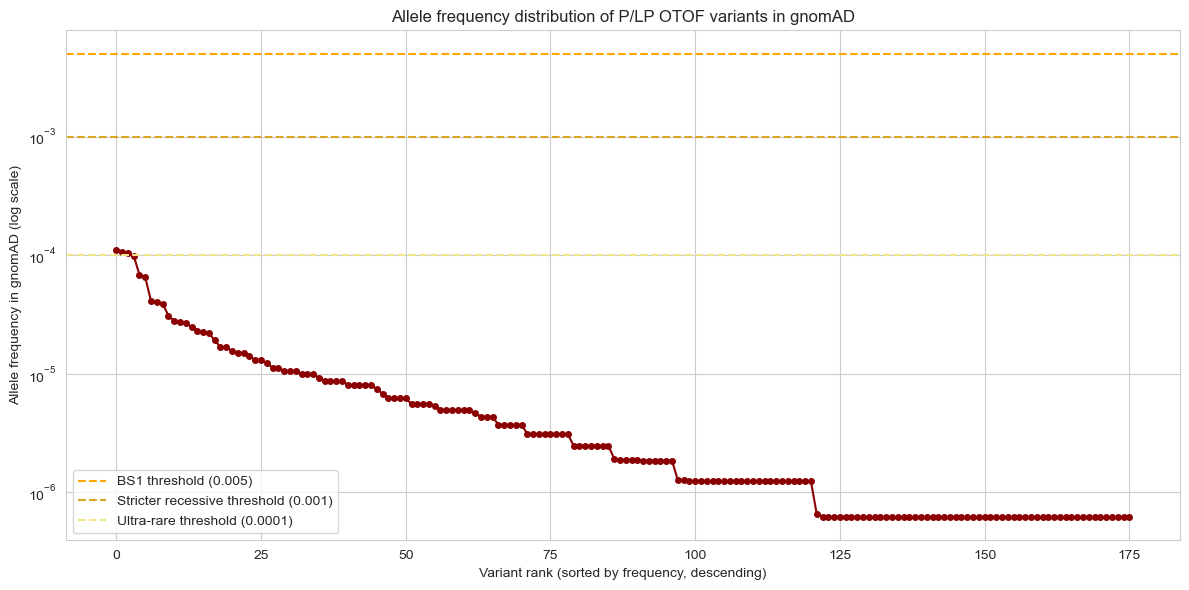

In [12]:
# Plot the frequency distribution of all P/LP variants
plp_variants = df_merged[
    df_merged["ClinVar Germline Classification"].isin(pathogenic_classes)
].sort_values("Allele Frequency", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(range(len(plp_variants)), plp_variants["Allele Frequency"],
         marker="o", linestyle="-", markersize=4, color="darkred")
plt.yscale("log")
plt.axhline(y=0.005, color="orange", linestyle="--", label="BS1 threshold (0.005)")
plt.axhline(y=0.001, color="goldenrod", linestyle="--", label="Stricter recessive threshold (0.001)")
plt.axhline(y=0.0001, color="khaki", linestyle="--", label="Ultra-rare threshold (0.0001)")
plt.title("Allele frequency distribution of P/LP OTOF variants in gnomAD")
plt.xlabel("Variant rank (sorted by frequency, descending)")
plt.ylabel("Allele frequency in gnomAD (log scale)")
plt.legend()
plt.tight_layout()
plt.savefig("../results/gnomad_plp_frequency_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
ancestries = [
    "African/African American",
    "Admixed American",
    "Ashkenazi Jewish",
    "East Asian",
    "European (Finnish)",
    "European (non-Finnish)",
    "Middle Eastern",
    "South Asian",
    "Amish",
]
pathogenic_classes = ["Pathogenic", "Likely pathogenic", "Pathogenic/Likely pathogenic"]

# Ensure df_merged exists
if "df_merged" not in globals():
    has_clinvar = gnomad["ClinVar Germline Classification"].notna()
    df_merged = gnomad[has_clinvar].copy()

# Compute ancestry-specific allele frequencies for P/LP variants
plp_variants = df_merged[
    df_merged["ClinVar Germline Classification"].isin(pathogenic_classes)
].copy()

for anc in ancestries:
    ac_col = f"Allele Count {anc}"
    an_col = f"Allele Number {anc}"
    plp_variants[f"AF {anc}"] = plp_variants[ac_col] / plp_variants[an_col].replace(0, np.nan)

print(f"Ready: {len(plp_variants)} P/LP variants with ancestry-specific AF.")


Ready: 176 P/LP variants with ancestry-specific AF.


In [14]:
print("Most frequent P/LP OTOF variant in each ancestry:\n")

for anc in ancestries:
    af_col = f"AF {anc}"
    subset = plp_variants.dropna(subset=[af_col])
    if len(subset) == 0:
        continue
    top = subset.sort_values(af_col, ascending=False).head(1).iloc[0]
    label = top["Protein Consequence"] if pd.notna(top["Protein Consequence"]) else top["HGVS Consequence"]
    af_value = top[af_col]
    print(f"{anc:30s} | {label:30s} | AF = {af_value:.5f}")

Most frequent P/LP OTOF variant in each ancestry:

African/African American       | p.Trp718Ter                    | AF = 0.00040
Admixed American               | p.Gln829Ter                    | AF = 0.00057
Ashkenazi Jewish               | c.5713-2A>G                    | AF = 0.00037
East Asian                     | p.Glu1700Gln                   | AF = 0.00339
European (Finnish)             | p.Arg237Ter                    | AF = 0.00009
European (non-Finnish)         | p.Arg963Ter                    | AF = 0.00015
Middle Eastern                 | p.Glu747Ter                    | AF = 0.00033
South Asian                    | p.Arg1583Cys                   | AF = 0.00004
Amish                          | p.Ter1231ArgextTer30           | AF = 0.00000


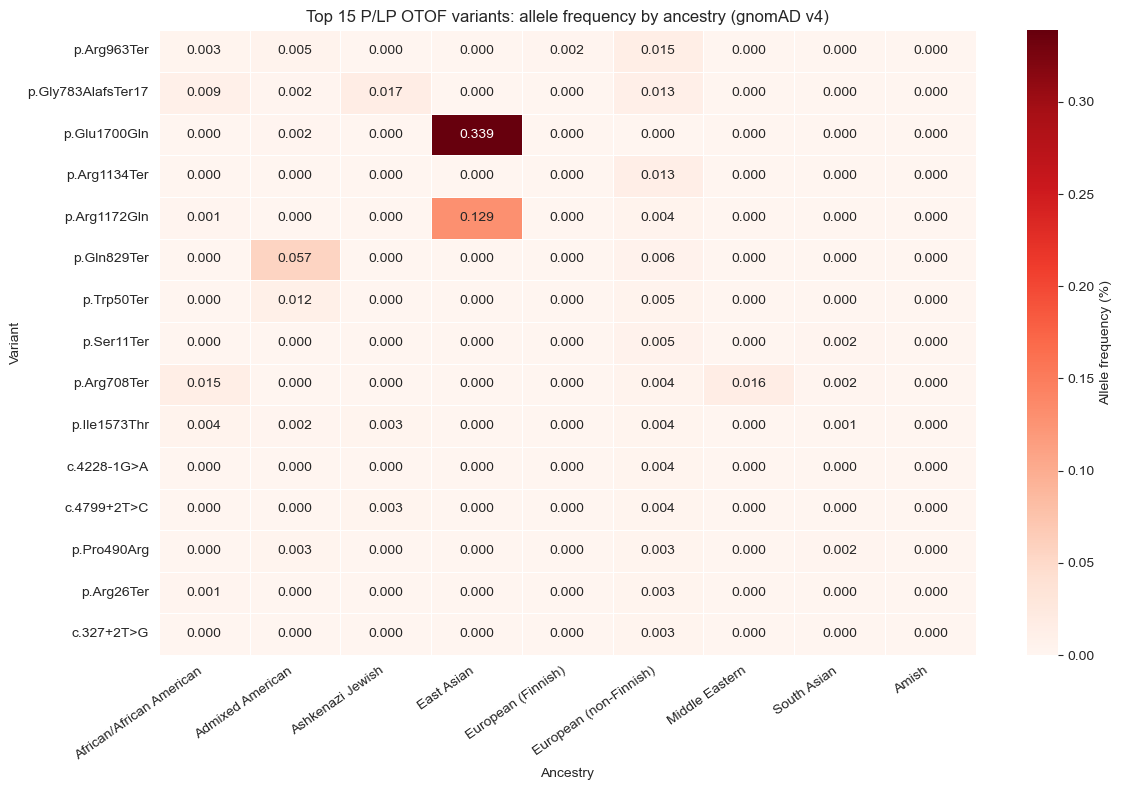

In [15]:
# Build a matrix: rows = top P/LP variants, columns = ancestries, values = AF
# Get the top 15 P/LP variants by global allele frequency
top15 = plp_variants.sort_values("Allele Frequency", ascending=False).head(15).copy()

# Build a clean label for each variant
def make_label(row):
    if pd.notna(row["Protein Consequence"]):
        return row["Protein Consequence"]
    return row["HGVS Consequence"]

top15["label"] = top15.apply(make_label, axis=1)

# Build the matrix
ancestry_af_cols = [f"AF {anc}" for anc in ancestries]
matrix = top15[["label"] + ancestry_af_cols].set_index("label")
matrix.columns = ancestries  # rename columns to clean names

# Convert to percentage for readability
matrix_pct = matrix * 100

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    matrix_pct,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    cbar_kws={"label": "Allele frequency (%)"},
    linewidths=0.5,
    linecolor="white",
)
plt.title("Top 15 P/LP OTOF variants: allele frequency by ancestry (gnomAD v4)")
plt.xlabel("Ancestry")
plt.ylabel("Variant")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/gnomad_ancestry_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
print("=" * 70)
print("KEY FINDINGS: OTOF VARIANTS IN gnomAD v4")
print("=" * 70)

print("\n1. DATASET OVERVIEW")
print(f"   Total gnomAD variants: {len(gnomad)}")
print(f"   Variants with ClinVar annotation: {has_clinvar.sum()}")
print(f"   ClinVar-annotated coverage: {100 * has_clinvar.sum() / len(gnomad):.1f}%")

af_median = gnomad["Allele Frequency"].median()
af_max = gnomad["Allele Frequency"].max()
print("\n2. ALLELE FREQUENCY DISTRIBUTION")
print(f"   Median AF: {af_median:.2e}")
print(f"   Max AF: {af_max:.4f}")

suspicious_count = len(suspicious)
plp_count = (df_merged["ClinVar Germline Classification"].isin(pathogenic_classes)).sum()
print("\n3. ACMG/AMP BS1 VALIDATION")
print(f"   P/LP variants total: {plp_count}")
print(f"   P/LP variants exceeding BS1 threshold (AF > 0.005): {suspicious_count}")
print("   All P/LP variants comply with population rarity expectations.")

plp_with_homozygotes = top_pathogenic[top_pathogenic["Homozygote Count"] > 0]
print("\n4. HOMOZYGOTES AMONG P/LP VARIANTS")
print(f"   P/LP variants with at least 1 homozygote in gnomAD: {len(plp_with_homozygotes)}")

print("\n5. ANCESTRY-SPECIFIC TOP P/LP VARIANTS")
for anc in ancestries:
    af_col = f"AF {anc}"
    subset = plp_variants.dropna(subset=[af_col])
    if len(subset) == 0:
        continue
    top = subset.sort_values(af_col, ascending=False).head(1).iloc[0]
    label = top["Protein Consequence"] if pd.notna(top["Protein Consequence"]) else top["HGVS Consequence"]
    af_value = top[af_col]
    if af_value > 0:
        print(f"   {anc:30s} | {label:30s} | AF = {af_value:.5f}")

ea_max = plp_variants["AF East Asian"].max()
print("\n6. NOTABLE FOUNDER EFFECT")
print(f"   Highest ancestry-specific AF: {ea_max:.5f} in East Asian (p.Glu1700Gln)")
print("   Strong founder effect; relevant for population-specific screening panels.")

print("\n" + "=" * 70)

KEY FINDINGS: OTOF VARIANTS IN gnomAD v4

1. DATASET OVERVIEW
   Total gnomAD variants: 9601
   Variants with ClinVar annotation: 1682
   ClinVar-annotated coverage: 17.5%

2. ALLELE FREQUENCY DISTRIBUTION
   Median AF: 1.24e-06
   Max AF: 0.6812

3. ACMG/AMP BS1 VALIDATION
   P/LP variants total: 176
   P/LP variants exceeding BS1 threshold (AF > 0.005): 0
   All P/LP variants comply with population rarity expectations.

4. HOMOZYGOTES AMONG P/LP VARIANTS
   P/LP variants with at least 1 homozygote in gnomAD: 3

5. ANCESTRY-SPECIFIC TOP P/LP VARIANTS
   African/African American       | p.Trp718Ter                    | AF = 0.00040
   Admixed American               | p.Gln829Ter                    | AF = 0.00057
   Ashkenazi Jewish               | c.5713-2A>G                    | AF = 0.00037
   East Asian                     | p.Glu1700Gln                   | AF = 0.00339
   European (Finnish)             | p.Arg237Ter                    | AF = 0.00009
   European (non-Finnish)       

## gnomAD Homozygotes Among P/LP Variants: Deep Dive

gnomAD applies a systematic exclusion policy: individuals with severe, early-onset
pediatric disease are removed from the database. Because autosomal recessive
deafness due to biallelic OTOF loss-of-function is a severe congenital condition,
homozygotes for P/LP OTOF variants in gnomAD are unexpected.

When a P/LP variant does appear as a homozygote in gnomAD, several explanations
are possible: (1) misclassification -- the variant may be benign or have incomplete
penetrance; (2) the phenotype is mild enough that affected individuals were not
excluded; (3) the gnomAD sample contains an undetected affected individual;
(4) the variant was identified in the heterozygous parent and the zygosity call is
a sequencing artifact. Each case warrants individual investigation.

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

data_dir = Path("../data")
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Load gnomAD data
gnomad = pd.read_csv(data_dir / "gnomad_otof_variants.csv", low_memory=False)

# Load ClinVar data
cols_to_drop = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24",
]
clinvar = pd.read_csv(data_dir / "clinvar_result.txt", sep="\t")
clinvar = clinvar.drop(columns=[c for c in cols_to_drop if c in clinvar.columns])

print(f"gnomAD variants loaded: {len(gnomad)}")
print(f"ClinVar variants loaded: {len(clinvar)}")


gnomAD variants loaded: 9601
ClinVar variants loaded: 2432


In [18]:
# ---------------------------------------------------------------------------
# Identify P/LP variants with homozygotes in gnomAD
# ---------------------------------------------------------------------------
GNOMAD_N = 730_000  # approximate gnomAD v4 diploid individual count

pathogenic_classes = ["Pathogenic", "Likely pathogenic", "Pathogenic/Likely pathogenic"]

# gnomAD rows with ClinVar P/LP classification and at least one homozygote
plp_gnomad = gnomad[
    gnomad["ClinVar Germline Classification"].isin(pathogenic_classes)
].copy()

homo_plp = plp_gnomad[plp_gnomad["Homozygote Count"] > 0].copy()

print(f"P/LP variants in gnomAD: {len(plp_gnomad)}")
print(f"P/LP variants with Homozygote Count > 0: {len(homo_plp)}")

# Ancestry columns for finding highest-AF ancestry
ancestries = [
    "African/African American", "Admixed American", "Ashkenazi Jewish",
    "East Asian", "European (Finnish)", "European (non-Finnish)",
    "Middle Eastern", "South Asian", "Amish",
]

def top_ancestry(row):
    """Return the ancestry with the highest allele frequency for this variant."""
    best_anc = None
    best_af = -1.0
    for anc in ancestries:
        ac_col = f"Allele Count {anc}"
        an_col = f"Allele Number {anc}"
        if ac_col in row.index and an_col in row.index:
            an = row[an_col]
            ac = row[ac_col]
            if an > 0:
                af = ac / an
                if af > best_af:
                    best_af = af
                    best_anc = anc
    return best_anc if best_anc else "N/A"


homo_plp["top_ancestry"] = homo_plp.apply(top_ancestry, axis=1)

# Hardy-Weinberg expected homozygote count
homo_plp["hw_expected_homos"] = homo_plp["Allele Frequency"] ** 2 * GNOMAD_N

# Match against ClinVar for review status and date
# ClinVar variant names contain various HGVS formats; match on protein consequence
def find_clinvar_info(protein_consequence):
    """Look up review status and date from ClinVar by protein consequence."""
    if pd.isna(protein_consequence):
        return "N/A", "N/A"
    # ClinVar 'Name' column often contains the protein change
    mask = clinvar["Name"].str.contains(
        re.escape(str(protein_consequence)), na=False, regex=True
    )
    subset = clinvar[mask]
    if len(subset) == 0:
        # Try 'Protein change' column
        mask2 = clinvar["Protein change"].str.contains(
            re.escape(str(protein_consequence)), na=False, regex=True
        )
        subset = clinvar[mask2]
    if len(subset) == 0:
        return "N/A", "N/A"
    # Take the most informative (first non-null)
    status = subset["Germline review status"].dropna()
    date   = subset["Germline date last evaluated"].dropna()
    return (status.iloc[0] if len(status) > 0 else "N/A",
            date.iloc[0]   if len(date)   > 0 else "N/A")

import re
homo_plp["clinvar_review_status"], homo_plp["clinvar_date"] = zip(
    *homo_plp["Protein Consequence"].apply(find_clinvar_info)
)

# Build output dataframe
output_cols = {
    "gnomAD ID": "gnomad_id",
    "Protein Consequence": "protein_consequence",
    "Allele Frequency": "allele_frequency",
    "Homozygote Count": "homozygote_count_observed",
    "ClinVar Germline Classification": "clinvar_classification",
    "top_ancestry": "top_ancestry",
    "hw_expected_homos": "hw_expected_homozygotes",
    "clinvar_review_status": "clinvar_review_status",
    "clinvar_date": "clinvar_date_last_evaluated",
}
homo_out = homo_plp.rename(columns=output_cols)[list(output_cols.values())].copy()
homo_out["hw_expected_homozygotes"] = homo_out["hw_expected_homozygotes"].round(4)

# Save
out_path = results_dir / "gnomad_homozygotes_analysis.csv"
homo_out.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

# Print detailed table
print("\nDetailed table of P/LP variants with gnomAD homozygotes:")
print("=" * 100)
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 200)
print(homo_out.to_string(index=False))
print("=" * 100)


P/LP variants in gnomAD: 176
P/LP variants with Homozygote Count > 0: 3

Saved: ../results/gnomad_homozygotes_analysis.csv

Detailed table of P/LP variants with gnomAD homozygotes:
     gnomad_id protein_consequence  allele_frequency  homozygote_count_observed clinvar_classification           top_ancestry  hw_expected_homozygotes                                clinvar_review_status clinvar_date_last_evaluated
2-26458218-C-T        p.Arg1172Gln          0.000068                          1             Pathogenic             East Asian                   0.0034 criteria provided, multiple submitters, no conflicts                 Aug 6, 2024
2-26463969-C-G        p.Glu1700Gln          0.000103                          1             Pathogenic             East Asian                   0.0078                             reviewed by expert panel                Jun 28, 2024
2-26476018-G-A         p.Arg963Ter          0.000111                          1             Pathogenic European (non-Finnis

### Interpretation

Possible explanations for P/LP OTOF homozygotes observed in gnomAD:

1. **Misclassification**: The variant may not be truly pathogenic. Older ClinVar
   submissions with "no assertion criteria provided" are prone to over-classification.
   A high-frequency P/LP variant found in a homozygous gnomAD individual supports
   downgrading (ACMG BS2 criterion).

2. **Incomplete penetrance**: OTOF variants associated with auditory neuropathy
   spectrum disorder (ANSD) rather than classic DFNB9 may have variable expressivity.
   Some biallelic carriers may have subclinical or compensated hearing loss.

3. **Mild phenotype**: If the homozygous individual was not excluded from gnomAD
   because their phenotype did not meet exclusion criteria (e.g., adult-onset mild
   loss), a homozygote could slip through.

4. **Sequencing artifact**: Somatic mosaicism or read misalignment could produce
   a false homozygous call, particularly in regions with low coverage or homology.

For each identified variant, comparison of observed vs. Hardy-Weinberg expected
homozygotes provides a quantitative signal: if observed >> HW-expected, enrichment
suggests a non-pathogenic or population-specific explanation rather than chance.